# **Sixth LangGraph**

## **Boilerplate**

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

if os.environ["OPENAI_API_KEY"]:
    print("OpenAI api key set")
else:
    raise ValueError("OpenAI api key is not set")

OpenAI api key set


## **DuckDuckGo Search Tool**

In [2]:
from langchain_openai import ChatOpenAI
from langchain_community.tools import DuckDuckGoSearchRun
from langchain.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, ToolMessage

llm = ChatOpenAI(model="gpt-4o-mini")

@tool
def ddg_tool(query: str):
    """
    this tool allows you to make a search query to duckduckgo
    """
    duck_search = DuckDuckGoSearchRun()

    return duck_search.invoke(query)



/var/folders/n0/2dw601qx3yz8y7snltq234hr0000gn/T/ipykernel_52039/4188087087.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


## **Custom Tool**

In [3]:


@tool
def personal_info(name: str):
    """
    Use this tool to get personal information about Alice, Bob, or Charlie
    """

    info = {
        "Alice": "Alice is a duke student",
        "Bob": "Bob is a builder",
        "Charlie": "Charlie is the CEO of the chair company"
    }
    return info.get(name, "No information for this person")



## **Tool Binding**

In [4]:
tools = [ddg_tool, personal_info]

llm_with_tools = llm.bind_tools(tools)

In [5]:
response = llm_with_tools.invoke("what is the latest news on langchain?")
response.tool_calls

[{'name': 'ddg_tool',
  'args': {'query': 'latest news on LangChain'},
  'id': 'call_sO5rQZJO2GHOXKMtbgSBqkfn',
  'type': 'tool_call'}]

## **LangGraph Creation**

### **Create Schema**

In [6]:
from typing import TypedDict, List
from typing import Annotated
from langgraph.graph.message import add_messages

# create graph schema
class graph_schema(TypedDict):
    messages: List

### **Create Node Functions**

In [7]:
# create llm node

def llm_node(state: graph_schema) -> graph_schema:

    messages = state['messages']

    prompt = ChatPromptTemplate.from_messages(
        [
        ("system", "you are a helpful assistant that can use tools to answer questions"),
        ("human", "{input}")
        ]
    )

    # llm_with_tools

    chain = prompt | llm_with_tools

    response = chain.invoke({"input": messages})

    state['messages'] = messages + [response]

    return state

In [8]:
# from langgraph.prebuilt import ToolNode
# ^ can use this, or make your own tool node and fully customize

def tool_node(state: graph_schema) -> graph_schema:

    messages = state['messages']

    tools_by_name = {tool.name: tool for tool in tools}

    tool_results = []

    for tool_call in messages[-1].tool_calls:

        tool = tools_by_name[tool_call['name']]

        observation = tool.invoke(tool_call['args'])

        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call['id']))

    state['messages'] = messages + tool_results

    return state

### **Create Conditional Edge Function**

In [9]:
from langgraph.graph import StateGraph, START, END

def if_tool_call(state: graph_schema) -> str:

    last_message = state['messages'][-1]

    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

### **Create State Graph**

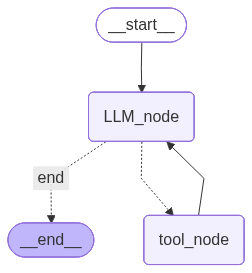

In [10]:
graph = StateGraph(graph_schema)

# Add nodes
graph.add_node("LLM_node", llm_node)
graph.add_node("tool_node", tool_node)

# Add edges (with new conditional edge this time)
graph.add_edge(START, "LLM_node")
graph.add_conditional_edges("LLM_node", if_tool_call, {"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "LLM_node")
graph.add_edge("LLM_node", END)

# compile graph
react_graph = graph.compile()

# display graph
from IPython.display import Image, display

Image(react_graph.get_graph().draw_mermaid_png())

### **Invoke ReAct Graph**

In [16]:
react_graph.invoke({"messages": [HumanMessage(content="who is charlie? first use the personal_info tool to find out, then: what does his company do? Please search ddg to find out")]})

{'messages': [HumanMessage(content='who is charlie? first use the personal_info tool to find out, then: what does his company do? Please search ddg to find out', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 138, 'total_tokens': 152, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_73ac716e3e', 'id': 'chatcmpl-E2nsRC3aqsQyC74fIjmD1pTgGw4lu', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f72c7-4a01-7f83-b618-9c53895eefe2-0', tool_calls=[{'name': 'personal_info', 'args': {'name': 'Charlie'}, 'id': 'call_EYX6aCVQPS2aarR5nn6IGfBN', 'typ

In [17]:
# get Messages as they populate instead:

for chunk in react_graph.stream(
    {"messages": [HumanMessage(content="who is charlie? first use the personal_info tool to find out, then: what does his company do? Please search ddg to find out")]},
    stream_mode="updates"
):
    print(chunk)

{'LLM_node': {'messages': [HumanMessage(content='who is charlie? first use the personal_info tool to find out, then: what does his company do? Please search ddg to find out', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 138, 'total_tokens': 152, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_73ac716e3e', 'id': 'chatcmpl-E2nycjQEdmuV47uV07BmmVrstJgJi', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f72cd-23ca-78d3-9466-01300c307213-0', tool_calls=[{'name': 'personal_info', 'args': {'name': 'Charlie'}, 'id': 'call_s2mQ8mwvEcMWifdqnMxx